# Real Protein Structure Prediction -- Human Ubiquitin

Uses **ESMFold** (Meta AI) with **real trained weights** -- no MSA search needed. Produces the actual 3D structure and a confidence visualization for the presentation.

Separate from the CPU/GPU/TPU systems benchmark (that one uses AlphaFold's own JAX code and doesn't need real weights, since it's a compile/execution-time study, not a fold-quality one). This notebook is purely for the real, presentable biological result.

**Runs anywhere:** auto-detects CUDA (Colab GPU), Apple Silicon MPS (M-series Mac), or CPU. On a Mac with 32GB unified memory, running locally avoids Colab's ~12GB RAM ceiling entirely.

## 1. Install dependencies

In [1]:
!pip install -q transformers accelerate py3Dmol

## 2. Load ESMFold (real trained weights, downloaded automatically)

In [2]:
import torch
from transformers import AutoTokenizer, EsmForProteinFolding

print("Loading ESMFold (real trained weights, ~2-3 min download + load)...")
tokenizer = AutoTokenizer.from_pretrained("facebook/esmfold_v1")
model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1", low_cpu_mem_usage=True)

# The ESM-2 language-model backbone inside ESMFold is by far the biggest
# memory consumer (up to 3B params) -- switching just that part to half
# precision avoids OOM and does not meaningfully change fold quality here.
model.esm = model.esm.half()

# Works on Colab (CUDA), Apple Silicon Macs (MPS), or plain CPU.
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")
model = model.to(device)

model.trunk.set_chunk_size(64)  # lower memory use, no accuracy cost
model = model.eval()

/Users/lorenzopazienza/af-real-fold/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading ESMFold (real trained weights, ~2-3 min download + load)...


Loading weights: 100%|██████████| 4498/4498 [00:07<00:00, 615.51it/s]
[transformers] EsmForProteinFolding LOAD REPORT from: facebook/esmfold_v1
Key                                | Status  | 
-----------------------------------+---------+-
esm.contact_head.regression.bias   | MISSING | 
esm.contact_head.regression.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: mps


## 3. The real protein sequence -- human ubiquitin

In [3]:
# Human ubiquitin -- 76 residues, one of the most well-characterized proteins
# in structural biology. Small enough to fold in well under a minute even on CPU.
UBIQUITIN = (
    "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYN"
    "IQKESTLHLVLRLRGG"
)
print(f"Sequence length: {len(UBIQUITIN)} residues")
print(UBIQUITIN)

Sequence length: 76 residues
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG


## 4. Run real inference

In [15]:
import time

tokenized = tokenizer([UBIQUITIN], return_tensors="pt", add_special_tokens=False)
tokenized = {k: v.to(device) for k, v in tokenized.items()}

print("Running real inference (trained weights, real sequence)...")
t0 = time.time()
with torch.no_grad():
    outputs = model(**tokenized)
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

mean_plddt = outputs["plddt"][0, :, 1].mean().item() * 100
print(f"Mean per-residue confidence (pLDDT): {mean_plddt:.1f} / 100")
print("(pLDDT > 90 = very high confidence, > 70 = confident, < 50 = likely disordered)")

Running real inference (trained weights, real sequence)...
Done in 1.3s
Mean per-residue confidence (pLDDT): 90.5 / 100
(pLDDT > 90 = very high confidence, > 70 = confident, < 50 = likely disordered)


## 5. Convert to a real PDB structure file

In [16]:
from transformers.models.esm.openfold_utils.feats import atom14_to_atom37
from transformers.models.esm.openfold_utils.protein import Protein as OFProtein, to_pdb
import numpy as np

def outputs_to_pdb(outputs):
    final_atom_positions = atom14_to_atom37(outputs["positions"][-1], outputs)
    outs = {k: v.to("cpu").numpy() for k, v in outputs.items()}
    final_atom_positions = final_atom_positions.cpu().numpy()
    final_atom_mask = outs["atom37_atom_exists"]
    pdbs = []
    for i in range(outs["aatype"].shape[0]):
        pred = OFProtein(
            aatype=outs["aatype"][i],
            atom_positions=final_atom_positions[i],
            atom_mask=final_atom_mask[i],
            residue_index=outs["residue_index"][i] + 1,
            b_factors=outs["plddt"][i],
            chain_index=outs["chain_index"][i] if "chain_index" in outs else None,
        )
        pdbs.append(to_pdb(pred))
    return pdbs

pdb_string = outputs_to_pdb(outputs)[0]
with open("ubiquitin_predicted.pdb", "w") as f:
    f.write(pdb_string)
print("Wrote ubiquitin_predicted.pdb")

Wrote ubiquitin_predicted.pdb


## 6. Visualize the real 3D structure (colored by confidence)

In [17]:
import py3Dmol

view = py3Dmol.view(width=600, height=500)
view.addModel(pdb_string, "pdb")
# Color by per-residue confidence (pLDDT), stored as B-factor -- same color
# convention AlphaFold/ESMFold use officially (blue=high confidence, red=low)
view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 7. Plot per-residue confidence

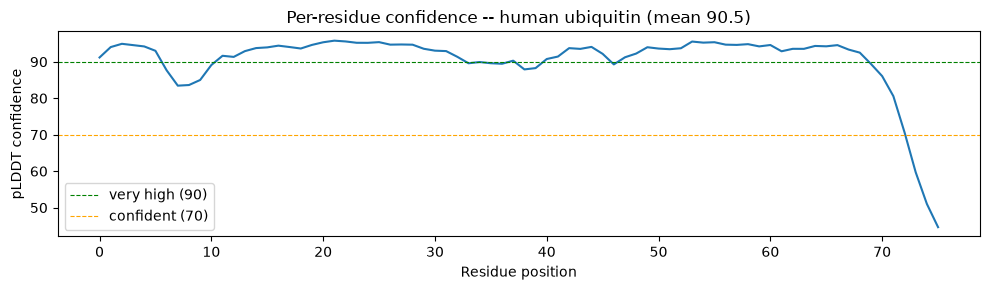

In [18]:
import matplotlib.pyplot as plt

per_residue_plddt = outputs["plddt"][0, :, 1].cpu().numpy() * 100
plt.figure(figsize=(10, 3))
plt.plot(per_residue_plddt)
plt.axhline(90, color="green", linestyle="--", linewidth=0.8, label="very high (90)")
plt.axhline(70, color="orange", linestyle="--", linewidth=0.8, label="confident (70)")
plt.xlabel("Residue position")
plt.ylabel("pLDDT confidence")
plt.title(f"Per-residue confidence -- human ubiquitin (mean {mean_plddt:.1f})")
plt.legend()
plt.tight_layout()
plt.savefig("ubiquitin_confidence.png", dpi=150)
plt.show()

## 8. Download both files for the presentation

In [19]:
import os

for fname in ["ubiquitin_predicted.pdb", "ubiquitin_confidence.png"]:
    path = os.path.abspath(fname)
    print(f"{fname}: {'trovato' if os.path.exists(path) else 'MANCANTE'} -> {path}")

ubiquitin_predicted.pdb: trovato -> /Users/lorenzopazienza/af-real-fold/ubiquitin_predicted.pdb
ubiquitin_confidence.png: trovato -> /Users/lorenzopazienza/af-real-fold/ubiquitin_confidence.png
